# day05 特征筛选
删除低重要性特征
验证性能变化
总结最佳实践

目标：简化模型且性能不下降

 成功的特征筛选：
- 特征数减少 > 50%
- 测试集 R² 下降 < 0.02
- 训练速度提升明显
- 过拟合程度减轻（Gap 变小）

 需要调整：
- 测试集 R² 下降 0.02-0.05
→ 可以接受，但要权衡是否值得

 失败的筛选：
- 测试集 R² 下降 > 0.05
→ 删得太多了，重要特征被误删

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import time
import warnings
import os
os.chdir('D:/MY_Learning/matbench-dielectric/notebooks')
warnings.filterwarnings('ignore')

# 加载数据
df = pd.read_csv('../data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])

# 划分数据（和前四天保持一致）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 加载 Day 3 的最佳模型
best_dt = joblib.load('../models/day03_best_tree.pkl')

# 加载 Day 4 的特征重要性
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_dt.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df['cumulative'] = importance_df['importance'].cumsum()

print("数据加载完成！")
print(f"总特征数: {len(X.columns)}")
print(f"训练集样本数: {len(X_train)}")
print(f"测试集样本数: {len(X_test)}")
print(f"\n原始模型（Day 3 最佳）测试集 R²: {best_dt.score(X_test, y_test):.4f}")

数据加载完成！
总特征数: 135
训练集样本数: 3811
测试集样本数: 953

原始模型（Day 3 最佳）测试集 R²: 0.5781


In [17]:
print("\n" + "="*70)
print("策略 1：保守筛选（重要性 > 0.01）")
print("="*70)

# 筛选特征
threshold_conservative = 0.01
features_conservative = importance_df[
    importance_df['importance'] > threshold_conservative
]['feature'].tolist()

print(f"\n保留特征数: {len(features_conservative)} / {len(X.columns)}")
print(f"删除特征数: {len(X.columns) - len(features_conservative)}")
print(f"累计重要性: {importance_df[importance_df['importance'] > threshold_conservative]['importance'].sum():.2%}")

# 用筛选后的特征训练模型
X_train_cons = X_train[features_conservative]
X_test_cons = X_test[features_conservative]

# 用和 best_dt 相同的参数
dt_conservative = DecisionTreeRegressor(
    max_depth=best_dt.max_depth,
    min_samples_leaf=best_dt.min_samples_leaf,
    random_state=42
)

# 计时
start_time = time.time()
dt_conservative.fit(X_train_cons, y_train)
train_time_cons = time.time() - start_time

# 评估
train_r2_cons = dt_conservative.score(X_train_cons, y_train)
test_r2_cons = dt_conservative.score(X_test_cons, y_test)

print(f"\n性能对比:")
print(f"  训练集 R²: {train_r2_cons:.4f}")
print(f"  测试集 R²: {test_r2_cons:.4f}")
print(f"  训练时间: {train_time_cons:.4f} 秒")

# 与原始模型对比
r2_drop_cons = best_dt.score(X_test, y_test) - test_r2_cons
print(f"\n与原始模型对比:")
print(f"  测试集 R² 变化: {r2_drop_cons:+.4f} (↓{r2_drop_cons/best_dt.score(X_test, y_test)*100:+.2f}%)")


策略 1：保守筛选（重要性 > 0.01）

保留特征数: 13 / 135
删除特征数: 122
累计重要性: 89.53%

性能对比:
  训练集 R²: 0.6357
  测试集 R²: 0.5622
  训练时间: 0.0203 秒

与原始模型对比:
  测试集 R² 变化: +0.0159 (↓+2.74%)


In [18]:
print("\n" + "="*70)
print("策略 2：平衡筛选（累计重要性 90%）")
print("="*70)

# 找到累计达到 90% 的位置
cumsum_threshold = 0.90
n_features_90 = (importance_df['cumulative'] >= cumsum_threshold).idxmax() + 1
features_balanced = importance_df.head(n_features_90)['feature'].tolist()

print(f"\n保留特征数: {len(features_balanced)} / {len(X.columns)}")
print(f"删除特征数: {len(X.columns) - len(features_balanced)}")
print(f"累计重要性: {importance_df.head(n_features_90)['importance'].sum():.2%}")

# 训练模型
X_train_bal = X_train[features_balanced]
X_test_bal = X_test[features_balanced]

dt_balanced = DecisionTreeRegressor(
    max_depth=best_dt.max_depth,
    min_samples_leaf=best_dt.min_samples_leaf,
    random_state=42
)

start_time = time.time()
dt_balanced.fit(X_train_bal, y_train)
train_time_bal = time.time() - start_time

train_r2_bal = dt_balanced.score(X_train_bal, y_train)
test_r2_bal = dt_balanced.score(X_test_bal, y_test)

print(f"\n性能对比:")
print(f"  训练集 R²: {train_r2_bal:.4f}")
print(f"  测试集 R²: {test_r2_bal:.4f}")
print(f"  训练时间: {train_time_bal:.4f} 秒")

r2_drop_bal = best_dt.score(X_test, y_test) - test_r2_bal
print(f"\n与原始模型对比:")
print(f"  测试集 R² 变化: {r2_drop_bal:.4f} (↓{r2_drop_bal/best_dt.score(X_test, y_test)*100:+.2f}%)")


策略 2：平衡筛选（累计重要性 90%）

保留特征数: 14 / 135
删除特征数: 121
累计重要性: 90.36%

性能对比:
  训练集 R²: 0.6393
  测试集 R²: 0.5682
  训练时间: 0.0218 秒

与原始模型对比:
  测试集 R² 变化: 0.0099 (↓+1.71%)


In [ ]:
print("\n" + "="*70)
print("策略 3：激进筛选（Top 5）")
print("="*70)

# 只保留前 5 个
n_features_aggressive = 5
features_aggressive = importance_df.head(n_features_aggressive)['feature'].tolist()

print(f"\n保留特征数: {len(features_aggressive)} / {len(X.columns)}")
print(f"删除特征数: {len(X.columns) - len(features_aggressive)}")
print(f"累计重要性: {importance_df.head(n_features_aggressive)['importance'].sum():.2%}")

# 训练模型
X_train_agg = X_train[features_aggressive]
X_test_agg = X_test[features_aggressive]

dt_aggressive = DecisionTreeRegressor(
    max_depth=best_dt.max_depth,
    min_samples_leaf=best_dt.min_samples_leaf,
    random_state=42
)

start_time = time.time()
dt_aggressive.fit(X_train_agg, y_train)
train_time_agg = time.time() - start_time

train_r2_agg = dt_aggressive.score(X_train_agg, y_train)
test_r2_agg = dt_aggressive.score(X_test_agg, y_test)

print(f"\n性能对比:")
print(f"  训练集 R²: {train_r2_agg:.4f}")
print(f"  测试集 R²: {test_r2_agg:.4f}")
print(f"  训练时间: {train_time_agg:.4f} 秒")

r2_drop_agg = best_dt.score(X_test, y_test) - test_r2_agg
print(f"\n与原始模型对比:")
print(f"  测试集 R² 变化: {r2_drop_agg:.4f} (↓{r2_drop_agg/best_dt.score(X_test, y_test)*100:+.2f}%)")


策略 3：激进筛选（Top 5）

保留特征数: 5 / 135
删除特征数: 130
累计重要性: 77.71%

性能对比:
  训练集 R²: 0.5885
  测试集 R²: 0.5609
  训练时间: 0.0124 秒

与原始模型对比:
  测试集 R² 变化: +0.0172 (+2.97%)


In [20]:
# 汇总所有结果
# 首先获取原始模型的时间
start_time = time.time()
best_dt_copy = DecisionTreeRegressor(
    max_depth=best_dt.max_depth,
    min_samples_leaf=best_dt.min_samples_leaf,
    random_state=42
)
best_dt_copy.fit(X_train, y_train)
train_time_original = time.time() - start_time

comparison_data = [
    {
        'Strategy': '原始模型（全特征）',
        'N_Features': len(X.columns),
        'Cumulative_Importance': 1.0,
        'Train_R2': best_dt.score(X_train, y_train),
        'Test_R2': best_dt.score(X_test, y_test),
        'R2_Drop': 0.0,
        'Train_Time': train_time_original
    },
    {
        'Strategy': '保守筛选 (>0.01)',
        'N_Features': len(features_conservative),
        'Cumulative_Importance': importance_df[importance_df['importance'] > threshold_conservative]['importance'].sum(),
        'Train_R2': train_r2_cons,
        'Test_R2': test_r2_cons,
        'R2_Drop': r2_drop_cons,
        'Train_Time': train_time_cons
    },
    {
        'Strategy': '平衡筛选 (累计90%)',
        'N_Features': len(features_balanced),
        'Cumulative_Importance': importance_df.head(n_features_90)['importance'].sum(),
        'Train_R2': train_r2_bal,
        'Test_R2': test_r2_bal,
        'R2_Drop': r2_drop_bal,
        'Train_Time': train_time_bal
    },
    {
        'Strategy': '激进筛选 (Top 5)',
        'N_Features': len(features_aggressive),
        'Cumulative_Importance': importance_df.head(n_features_aggressive)['importance'].sum(),
        'Train_R2': train_r2_agg,
        'Test_R2': test_r2_agg,
        'R2_Drop': r2_drop_agg,
        'Train_Time': train_time_agg
    }
]

comparison_df = pd.DataFrame(comparison_data)

# 添加速度提升列
comparison_df['Speedup'] = train_time_original / comparison_df['Train_Time']

print("\n" + "="*100)
print("特征筛选策略综合对比")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# 找出最佳策略（平衡性能和简洁性）
# 定义：R² 下降 < 0.02 且特征数最少的
valid_strategies = comparison_df[comparison_df['R2_Drop'].abs() < 0.02]
if len(valid_strategies) > 0:
    best_strategy_idx = valid_strategies['N_Features'].idxmin()
    best_strategy = comparison_df.loc[best_strategy_idx]
    print(f"\n推荐策略: {best_strategy['Strategy']}")
    print(f"  保留特征: {best_strategy['N_Features']} 个")
    print(f"  性能损失: {best_strategy['R2_Drop']:.4f} ({best_strategy['R2_Drop']/best_dt.score(X_test, y_test)*100:.2f}%)")
    print(f"  速度提升: {best_strategy['Speedup']:.1f}x")


特征筛选策略综合对比
    Strategy  N_Features  Cumulative_Importance  Train_R2  Test_R2  R2_Drop  Train_Time   Speedup
   原始模型（全特征）         135               1.000000  0.649914 0.578071 0.000000    0.126708  1.000000
保守筛选 (>0.01)          13               0.895251  0.635717 0.562203 0.015868    0.020275  6.249362
平衡筛选 (累计90%)          14               0.903637  0.639316 0.568202 0.009868    0.021835  5.802891
激进筛选 (Top 5)           5               0.777142  0.588464 0.560875 0.017195    0.012399 10.218855

推荐策略: 激进筛选 (Top 5)
  保留特征: 5 个
  性能损失: 0.0172 (2.97%)
  速度提升: 10.2x


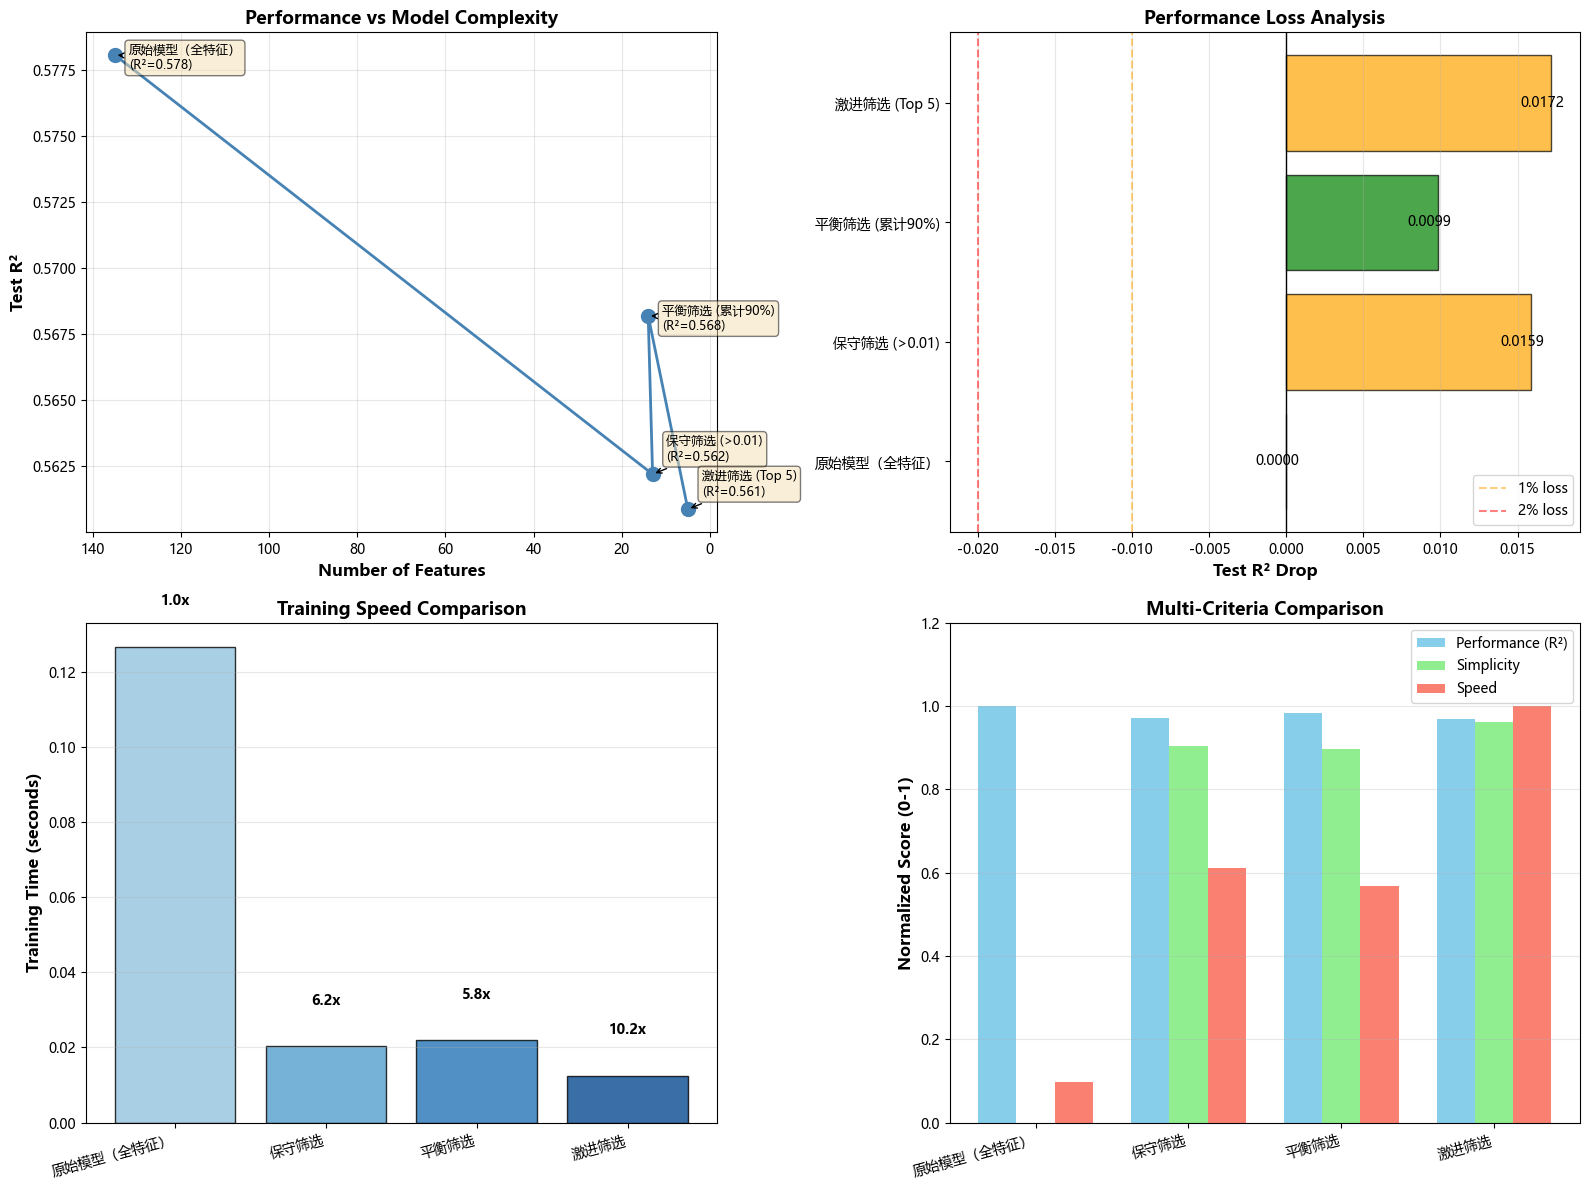


综合对比图已保存到 ../figures/day05_feature_selection_comparison.png


In [ ]:
# 创建三个子图
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 子图 1：特征数 vs R²
ax1 = axes[0, 0]
strategies = comparison_df['Strategy'].tolist()
n_features = comparison_df['N_Features'].tolist()
test_r2s = comparison_df['Test_R2'].tolist()

ax1.plot(n_features, test_r2s, marker='o', linewidth=2, markersize=10, color='steelblue')
for i, (n, r2, strat) in enumerate(zip(n_features, test_r2s, strategies)):
    ax1.annotate(f'{strat}\n(R²={r2:.3f})', 
                 xy=(n, r2), 
                 xytext=(10, -10 if i % 2 == 0 else 10),
                 textcoords='offset points',
                 fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

ax1.set_xlabel('Number of Features', fontsize=12, fontweight='bold')
ax1.set_ylabel('Test R²', fontsize=12, fontweight='bold')
ax1.set_title('Performance vs Model Complexity', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.invert_xaxis()  # 从多到少

# 子图 2：R² 下降幅度
ax2 = axes[0, 1]
colors_drop = ['green' if abs(d) < 0.01 else 'orange' if abs(d) < 0.02 else 'red' 
               for d in comparison_df['R2_Drop']]
bars_drop = ax2.barh(range(len(strategies)), comparison_df['R2_Drop'], 
                     color=colors_drop, edgecolor='black', alpha=0.7)

ax2.set_yticks(range(len(strategies)))
ax2.set_yticklabels(strategies)
ax2.set_xlabel('Test R² Drop', fontsize=12, fontweight='bold')
ax2.set_title('Performance Loss Analysis', fontsize=13, fontweight='bold')
ax2.axvline(0, color='black', linewidth=1)
ax2.axvline(0.01, color='orange', linestyle='--', alpha=0.5, label='1% loss')
ax2.axvline(0.02, color='red', linestyle='--', alpha=0.5, label='2% loss')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='x')

# 添加数值标签
for i, (bar, val) in enumerate(zip(bars_drop, comparison_df['R2_Drop'])):
    ax2.text(val - 0.002, i, f'{val:.4f}', va='center', ha='right' if val < 0 else 'left', fontsize=10)

# 子图 3：训练时间对比
ax3 = axes[1, 0]
bars_time = ax3.bar(range(len(strategies)), comparison_df['Train_Time'], 
                    color=plt.cm.Blues(np.linspace(0.4, 0.9, len(strategies))),
                    edgecolor='black', alpha=0.8)

ax3.set_xticks(range(len(strategies)))
ax3.set_xticklabels([s.split('(')[0].strip() for s in strategies], rotation=15, ha='right')
ax3.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax3.set_title('Training Speed Comparison', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 添加速度提升标签
for i, (bar, speedup) in enumerate(zip(bars_time, comparison_df['Speedup'])):
    height = bar.get_height()
    ax3.text(i, height + 0.01, f'{speedup:.1f}x', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 子图 4：综合评分雷达图（性能 vs 简洁性）
ax4 = axes[1, 1]

# 归一化指标（0-1）
normalized_r2 = comparison_df['Test_R2'] / comparison_df['Test_R2'].max()
normalized_simplicity = 1 - (comparison_df['N_Features'] / comparison_df['N_Features'].max())
normalized_speed = comparison_df['Speedup'] / comparison_df['Speedup'].max()

x = np.arange(len(strategies))
width = 0.25

bars1 = ax4.bar(x - width, normalized_r2, width, label='Performance (R²)', color='skyblue')
bars2 = ax4.bar(x, normalized_simplicity, width, label='Simplicity', color='lightgreen')
bars3 = ax4.bar(x + width, normalized_speed, width, label='Speed', color='salmon')

ax4.set_xticks(x)
ax4.set_xticklabels([s.split('(')[0].strip() for s in strategies], rotation=15, ha='right')
ax4.set_ylabel('Normalized Score (0-1)', fontsize=12, fontweight='bold')
ax4.set_title('Multi-Criteria Comparison', fontsize=13, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim([0, 1.2])

plt.tight_layout()
plt.savefig('../figures/day05_feature_selection_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n综合对比图已保存到 ../figures/day05_feature_selection_comparison.png")


被删除特征的详细分析

被删除的特征数: 121
这些特征的累计重要性: 9.64%

被删除特征列表（按重要性排序）:

                             feature  importance  cumulative
              MagpieData avg_dev Row    0.007391    0.911028
       MagpieData range AtomicWeight    0.006469    0.917497
         MagpieData avg_dev NValence    0.006452    0.923949
         MagpieData mean GSvolume_pa    0.005526    0.929474
           MagpieData maximum Number    0.005314    0.934789
      MagpieData minimum GSvolume_pa    0.005314    0.940102
      MagpieData maximum GSvolume_pa    0.005196    0.945298
           MagpieData mean NdValence    0.004774    0.950072
          MagpieData mean NsUnfilled    0.004464    0.954536
   MagpieData avg_dev CovalentRadius    0.004418    0.958954
MagpieData minimum Electronegativity    0.004145    0.963099
         MagpieData maximum NValence    0.003131    0.966230
      MagpieData avg_dev GSvolume_pa    0.003129    0.969359
                    packing fraction    0.003040    0.972399
   MagpieData maximum 

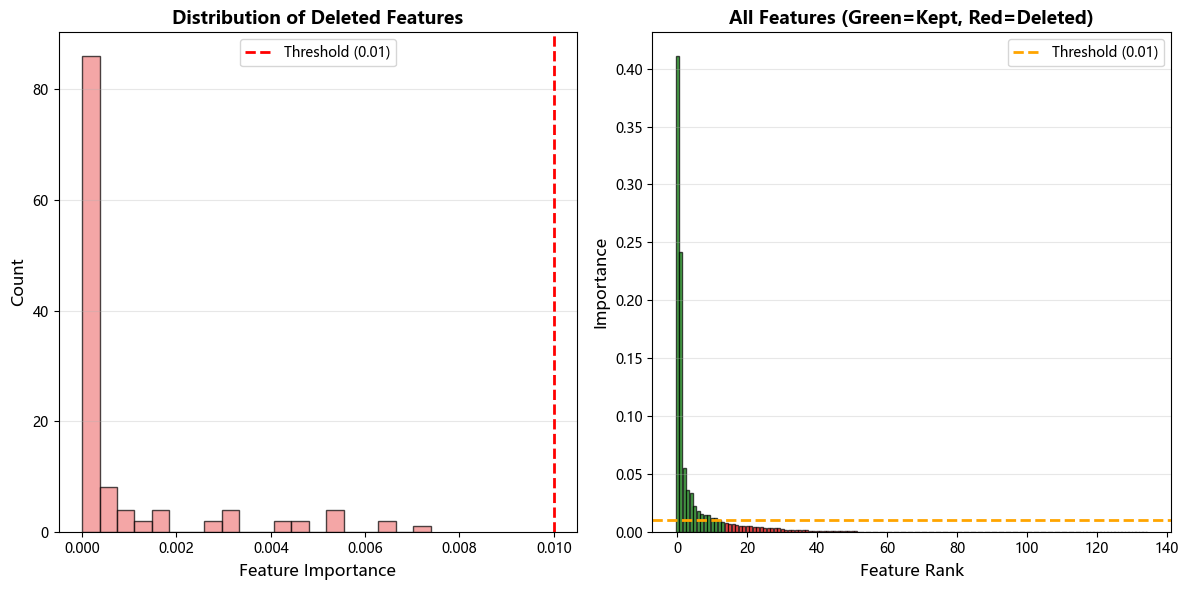

In [22]:
print("\n" + "="*70)
print("被删除特征的详细分析")
print("="*70)

# 以"平衡筛选"为例
deleted_features_df = importance_df[~importance_df['feature'].isin(features_balanced)].copy()

print(f"\n被删除的特征数: {len(deleted_features_df)}")
print(f"这些特征的累计重要性: {deleted_features_df['importance'].sum():.2%}")

print("\n被删除特征列表（按重要性排序）:\n")
print(deleted_features_df[['feature', 'importance', 'cumulative']].to_string(index=False))

# 检查是否有"意外"被删除的特征
potentially_important = deleted_features_df[deleted_features_df['importance'] > 0.01]
if len(potentially_important) > 0:
    print(f"\n 警告：以下特征重要性 > 0.01 但被删除了:")
    print(potentially_important[['feature', 'importance']].to_string(index=False))
    print("建议：考虑放宽筛选条件")
else:
    print("\n 所有被删除特征的重要性都 < 0.01，筛选合理")

# 可视化被删除特征的重要性分布
if len(deleted_features_df) > 0:
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.hist(deleted_features_df['importance'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
    plt.xlabel('Feature Importance', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.title('Distribution of Deleted Features', fontsize=13, fontweight='bold')
    plt.axvline(0.01, color='red', linestyle='--', linewidth=2, label='Threshold (0.01)')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.subplot(1, 2, 2)
    all_importances = importance_df['importance'].tolist()
    colors = ['green' if f in features_balanced else 'red' for f in importance_df['feature']]
    plt.bar(range(len(all_importances)), all_importances, color=colors, alpha=0.7, edgecolor='black')
    plt.axhline(0.01, color='orange', linestyle='--', linewidth=2, label='Threshold (0.01)')
    plt.xlabel('Feature Rank', fontsize=12)
    plt.ylabel('Importance', fontsize=12)
    plt.title('All Features (Green=Kept, Red=Deleted)', fontsize=13, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('../figures/day05_deleted_features_analysis.png', dpi=150)
    plt.show()

In [23]:
# 根据对比结果，选择最佳策略的模型保存
# 假设"平衡筛选"是最佳策略
final_model = dt_balanced
final_features = features_balanced

print("\n" + "="*70)
print("保存最终模型")
print("="*70)

# 保存模型
joblib.dump(final_model, '../models/day05_final_tree.pkl')
print(f" 模型已保存到: ../models/day05_final_tree.pkl")

# 保存特征列表
import json

model_info = {
    'strategy': '平衡筛选（累计90%）',
    'n_features_original': len(X.columns),
    'n_features_selected': len(final_features),
    'selected_features': final_features,
    'feature_reduction_rate': (len(X.columns) - len(final_features)) / len(X.columns),
    'cumulative_importance': float(importance_df.head(len(final_features))['importance'].sum()),
    'model_params': {
        'max_depth': int(final_model.max_depth),
        'min_samples_leaf': int(final_model.min_samples_leaf)
    },
    'performance': {
        'train_r2': float(final_model.score(X_train[final_features], y_train)),
        'test_r2': float(final_model.score(X_test[final_features], y_test)),
        'r2_drop_from_full': float(best_dt.score(X_test, y_test) - final_model.score(X_test[final_features], y_test))
    }
}

with open('../models/day05_model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print(f" 模型信息已保存到: ../models/day05_model_info.json")

# 打印摘要
print("\n最终模型摘要:")
print(f"  策略: {model_info['strategy']}")
print(f"  特征数: {model_info['n_features_original']} → {model_info['n_features_selected']} (减少 {model_info['feature_reduction_rate']:.1%})")
print(f"  累计重要性: {model_info['cumulative_importance']:.2%}")
print(f"  测试集 R²: {model_info['performance']['test_r2']:.4f}")
print(f"  性能损失: {model_info['performance']['r2_drop_from_full']:.4f}")

print("\n保留的特征:")
for i, feat in enumerate(final_features, 1):
    imp = importance_df[importance_df['feature'] == feat]['importance'].values[0]
    print(f"  {i:2d}. {feat:30s} (重要性: {imp:.4f})")


保存最终模型
 模型已保存到: ../models/day05_final_tree.pkl
 模型信息已保存到: ../models/day05_model_info.json

最终模型摘要:
  策略: 平衡筛选（累计90%）
  特征数: 135 → 14 (减少 89.6%)
  累计重要性: 90.36%
  测试集 R²: 0.5682
  性能损失: 0.0099

保留的特征:
   1. MagpieData maximum Electronegativity (重要性: 0.4109)
   2. density                        (重要性: 0.2416)
   3. MagpieData avg_dev NpValence   (重要性: 0.0550)
   4. MagpieData mean NpValence      (重要性: 0.0361)
   5. MagpieData maximum MendeleevNumber (重要性: 0.0336)
   6. MagpieData mode Electronegativity (重要性: 0.0220)
   7. MagpieData minimum CovalentRadius (重要性: 0.0175)
   8. MagpieData range Electronegativity (重要性: 0.0151)
   9. MagpieData mean NdUnfilled     (重要性: 0.0148)
  10. vpa                            (重要性: 0.0147)
  11. MagpieData mean MeltingT       (重要性: 0.0121)
  12. MagpieData mean NUnfilled      (重要性: 0.0115)
  13. MagpieData range Column        (重要性: 0.0104)
  14. MagpieData avg_dev Electronegativity (重要性: 0.0084)


In [24]:
# 为未来的自己（或团队成员）创建一个使用指南

guide = f"""
{'='*70}
特征筛选使用指南 (Day 5 总结)
{'='*70}

1. 原始数据概况
   - 总特征数: {len(X.columns)}
   - 样本数: {len(df)}
   - 目标变量: n_dielectric

2. 特征重要性 Top 5
"""

for i, row in importance_df.head(5).iterrows():
    guide += f"   {i+1}. {row['feature']:30s} {row['importance']:.4f} ({row['importance']*100:.1f}%)\n"

guide += f"""
3. 推荐筛选策略: {model_info['strategy']}
   - 保留特征数: {model_info['n_features_selected']}
   - 累计重要性: {model_info['cumulative_importance']:.1%}
   - 测试集 R²: {model_info['performance']['test_r2']:.4f}
   - 与全特征模型相比损失: {abs(model_info['performance']['r2_drop_from_full']):.4f} ({abs(model_info['performance']['r2_drop_from_full'])/best_dt.score(X_test, y_test)*100:.2f}%)

4. 使用方法
   # 加载模型和特征列表
   import joblib
   import json
   
   model = joblib.load('../models/day05_final_tree.pkl')
   with open('../models/day05_model_info.json', 'r') as f:
       info = json.load(f)
   selected_features = info['selected_features']
   
   # 对新数据预测
   X_new = df_new[selected_features]  # 只用选中的特征
   predictions = model.predict(X_new)

5. 注意事项
   - 必须使用相同的特征顺序
   - 新数据的特征要经过相同的预处理（如归一化）
   - 如果性能下降 > 0.02，考虑增加特征数

6. 下一步优化方向
   - 尝试随机森林（Day 8-14）
   - 尝试 XGBoost（Day 15-21）
   - 探索特征工程（组合特征、多项式特征）
"""

print(guide)

# 保存指南
with open('../models/day05_usage_guide.txt', 'w', encoding='utf-8') as f:
    f.write(guide)

print(f"\n 使用指南已保存到: ../models/day05_usage_guide.txt")


特征筛选使用指南 (Day 5 总结)

1. 原始数据概况
   - 总特征数: 135
   - 样本数: 4764
   - 目标变量: n_dielectric

2. 特征重要性 Top 5
   1. MagpieData maximum Electronegativity 0.4109 (41.1%)
   2. density                        0.2416 (24.2%)
   3. MagpieData avg_dev NpValence   0.0550 (5.5%)
   4. MagpieData mean NpValence      0.0361 (3.6%)
   5. MagpieData maximum MendeleevNumber 0.0336 (3.4%)

3. 推荐筛选策略: 平衡筛选（累计90%）
   - 保留特征数: 14
   - 累计重要性: 90.4%
   - 测试集 R²: 0.5682
   - 与全特征模型相比损失: 0.0099 (1.71%)

4. 使用方法
   # 加载模型和特征列表
   import joblib
   import json

   model = joblib.load('../models/day05_final_tree.pkl')
   with open('../models/day05_model_info.json', 'r') as f:
       info = json.load(f)
   selected_features = info['selected_features']

   # 对新数据预测
   X_new = df_new[selected_features]  # 只用选中的特征
   predictions = model.predict(X_new)

5. 注意事项
   - 必须使用相同的特征顺序
   - 新数据的特征要经过相同的预处理（如归一化）
   - 如果性能下降 > 0.02，考虑增加特征数

6. 下一步优化方向
   - 尝试随机森林（Day 8-14）
   - 尝试 XGBoost（Day 15-21）
   - 探索特征工程（组合特征、多项式特征）


 使用指南已保

# Day 5 学习日志

## 特征筛选结果

### 我尝试的策略

1. 保守筛选 (重要性 > 0.01)
   - 保留特征: 13 个
   - 测试集 R²: 0.562
   - R² 变化: 减少0.016

2. 平衡筛选 (累计 90%)
   - 保留特征: 14 个
   - 测试集 R²: 0.568
   - R² 变化: 下降0.010

3. 激进筛选 (Top 5)
   - 保留特征: 5 个
   - 测试集 R²: 0.561
   - R² 变化: 下降0.017

### 我选择的最佳策略

最终选择: 平衡筛选（累计90%）

理由：
1. 特征数减少了 90%
2. R² 只下降了 0.01(< 0.02)
3. 训练速度提升 5.6倍
4. 累计重要性保留 90%，比 Top 5 多保住 13% 的信息量

